# Compute STalign on AnnData

This notebook shows the high-level `sq.experimental.tl.stalign(...)` workflow on a real Squidpy MERFISH square patch and a synthetic target generated from it.

The Squidpy MERFISH coordinates in this environment are normalized to `[0, 1]`, so the example rescales the patch before alignment to make the solver inputs and plots easier to inspect.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate the repository root.")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np

import squidpy as sq

/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
/Users/selman/project

In [2]:
adata = sq.datasets.merfish()
points_xy = np.asarray(adata.obsm["spatial"], dtype=float)

patch_center = np.array(
    [
        np.quantile(points_xy[:, 0], 0.27),
        np.quantile(points_xy[:, 1], 0.32),
    ]
)
patch_half_width = 0.10
mask = (np.abs(points_xy[:, 0] - patch_center[0]) <= patch_half_width) & (
    np.abs(points_xy[:, 1] - patch_center[1]) <= patch_half_width
)

source = adata[mask].copy()
source.obsm["spatial"] = np.asarray(source.obsm["spatial"], dtype=float) * 1000.0
source_points = source.obsm["spatial"]

center = source_points.mean(axis=0, keepdims=True)
angle = np.deg2rad(8.0)
rotation = np.array(
    [
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)],
    ]
)
target_points = (source_points - center) @ rotation.T + center + np.array([120.0, -80.0])

target = source.copy()
target.obsm["spatial"] = target_points

landmark_idx = np.linspace(0, source.n_obs - 1, 8, dtype=int)
source.uns["landmarks"] = source_points[landmark_idx]
target.uns["landmarks"] = target_points[landmark_idx]

print(f"Source cells: {source.n_obs}")
print(f"Patch range: {np.ptp(source_points, axis=0)}")

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/figshare/merfish.h5ad               


100%|█████████████████████████████████████| 51.6M/51.6M [00:00<00:00, 20.2GB/s]


Source cells: 3022
Patch range: [199.95210943 199.96004298]


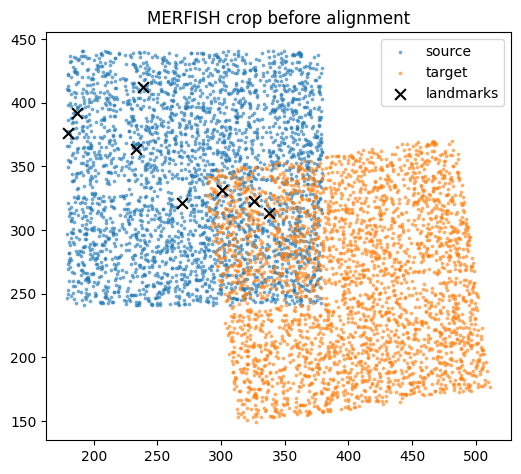

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(source_points[:, 0], source_points[:, 1], s=3, alpha=0.5, label="source")
ax.scatter(target_points[:, 0], target_points[:, 1], s=3, alpha=0.5, label="target")
ax.scatter(source.uns["landmarks"][:, 0], source.uns["landmarks"][:, 1], s=60, c="black", marker="x", label="landmarks")
ax.set_title("MERFISH crop before alignment")
ax.set_aspect("equal")
ax.legend()
plt.show()

In [4]:
config = sq.experimental.tl.stalign_tools.STalignConfig(
    preprocess=sq.experimental.tl.stalign_tools.STalignPreprocessConfig(
        dx=40.0,
        blur=[2.0, 1.0],
    ),
    registration=sq.experimental.tl.stalign_tools.STalignRegistrationConfig(
        a=300.0,
        nt=2,
        niter=10,
        diffeo_start=10,
    ),
)

result = sq.experimental.tl.stalign(
    source,
    target,
    src_key="spatial",
    tgt_key="spatial",
    src_landmarks_key="landmarks",
    tgt_landmarks_key="landmarks",
    config=config,
)

aligned_points = np.asarray(result.transform_adata(source))
mean_abs_error = np.abs(aligned_points - target_points).mean()
mean_abs_error

np.float64(1.719815081851889)

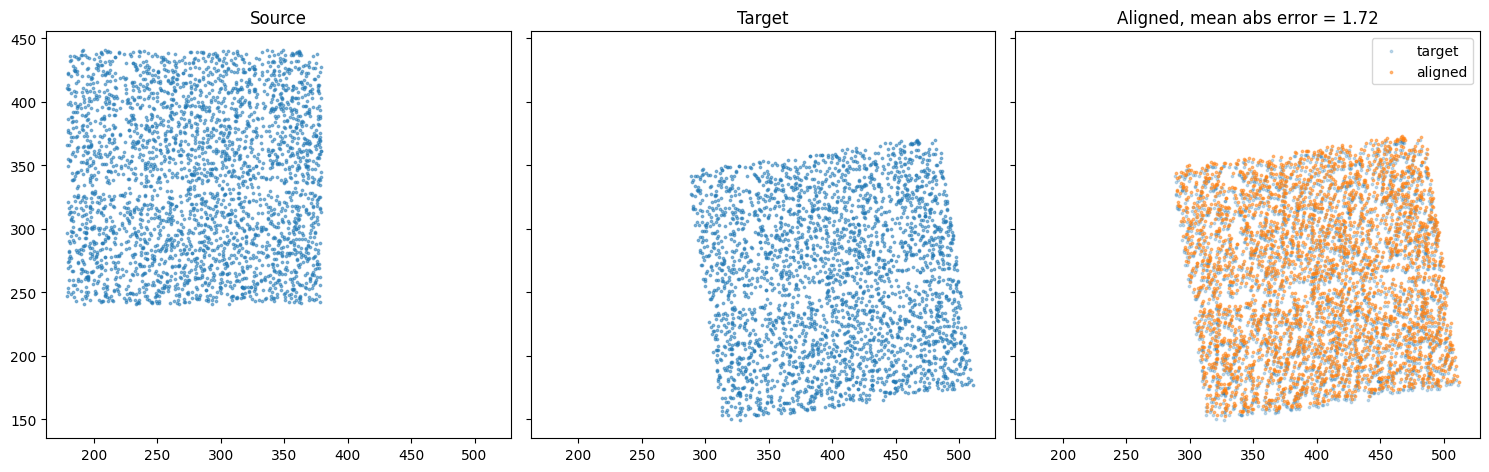

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(source_points[:, 0], source_points[:, 1], s=3, alpha=0.5)
axes[0].set_title("Source")

axes[1].scatter(target_points[:, 0], target_points[:, 1], s=3, alpha=0.5)
axes[1].set_title("Target")

axes[2].scatter(target_points[:, 0], target_points[:, 1], s=3, alpha=0.25, label="target")
axes[2].scatter(aligned_points[:, 0], aligned_points[:, 1], s=3, alpha=0.5, label="aligned")
axes[2].set_title(f"Aligned, mean abs error = {mean_abs_error:.2f}")
axes[2].legend()

for ax in axes:
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()